In [46]:

from pathlib import Path
from typing import List, Optional, Tuple
import tifffile
from skimage.morphology import white_tophat
import napari
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.filters import (
    gaussian,
    threshold_li,
    threshold_mean,
    threshold_triangle,
    try_all_threshold,
    threshold_otsu,
    threshold_minimum,
    
)
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import (
    closing,
    disk,
    erosion,
    h_maxima,
    remove_small_holes,
    remove_small_objects
)
from skimage.segmentation import expand_labels, watershed
from skimage.filters import threshold_yen
from skimage.filters import median as median_filter
from skimage.morphology import square


In [ ]:
folder = Path(r"Z:\Bel\Marina_Side_Projects\CART analysis\To_Do\Outputs\stage3")
tif_files = sorted(folder.glob("**/*.tif"))

In [51]:
test = tifffile.imread(tif_files[5])

In [20]:
_CH_BF = 0
_CH_BCELL_RAW = 1
_CH_VASC_RAW = 2
_CH_CART_RAW = 3
_CH_CHIP = 4
_CH_TUMOUR = 5
_CH_LEFT = 6
_CH_RIGHT = 7
_CH_VASC_MASK = 8
_CH_BCELL_MASK = 9
_CH_CART_MASK = 10

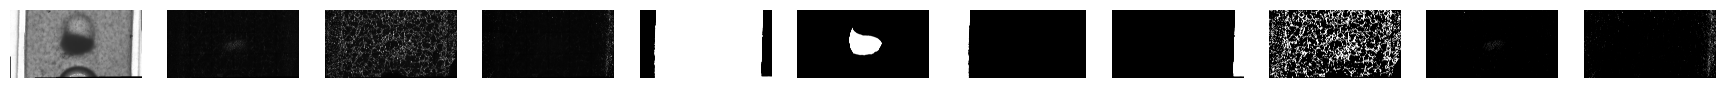

In [21]:
n_channels = test.shape[0]
fig, ax = plt.subplots(ncols = n_channels, figsize=(2*n_channels, 3))
for i in range(n_channels):
    ax[i].imshow(test[i,:,:], cmap="gray")
    ax[i].axis("off")

In [57]:
def segment_bcells(image):
    raw_bcells = image[_CH_BCELL_RAW,:,:]
    bg_removed = white_tophat(raw_bcells, footprint=disk(5))
    bcell_seg_bg = bg_removed > threshold_triangle(bg_removed)
    bcell_seg_bg = remove_small_objects(bcell_seg_bg, min_size=2)
    image[_CH_BCELL_MASK, :, :] = bcell_seg_bg
def segment_cart_cells(image):
    raw_cartcells = image[_CH_CART_RAW,:,:]
    bg_removed_CART = white_tophat(raw_cartcells, footprint=disk(5))
    CART_seg_bg = bg_removed_CART > threshold_triangle(bg_removed_CART)
    CART_seg_bg = remove_small_objects(CART_seg_bg, min_size=2)
    image[_CH_CART_MASK, :, :] = CART_seg_bg
def segment_vasculature(image):
    raw_vasculature = image[_CH_VASC_RAW,:,:]
    raw_vasculature.max(), raw_vasculature.min()
    vasc_med = median_filter(raw_vasculature, footprint=square(7))
    smooth_vasc = gaussian(vasc_med, sigma=3)
    seg = smooth_vasc > threshold_mean(smooth_vasc)
    image[_CH_VASC_MASK,:,:] = seg


In [58]:
output_folder = Path(r"Z:\Bel\Marina_Side_Projects\CART analysis\To_Do\Outputs\overwritten_segmentation")
output_folder.mkdir(parents=True, exist_ok=True)

for tif_path in tif_files:
    # Read full image plus original metadata so we can write it back unchanged
    with tifffile.TiffFile(tif_path) as tf:
        image = tf.asarray()
        imagej_metadata = tf.imagej_metadata
        ome_metadata = tf.ome_metadata
        is_imagej = tf.is_imagej
        is_ome = tf.is_ome
        first_page = tf.pages[0]
        resolution = first_page.tags.get("XResolution"), first_page.tags.get("YResolution")
        resolution_unit = first_page.tags.get("ResolutionUnit")
        x_res = first_page.tags["XResolution"].value if "XResolution" in first_page.tags else None
        y_res = first_page.tags["YResolution"].value if "YResolution" in first_page.tags else None

    # Overwrite only the three mask channels in-place
    segment_bcells(image)
    segment_cart_cells(image)
    segment_vasculature(image)

    out_path = output_folder / tif_path.name

    write_kwargs = {}
    if x_res is not None and y_res is not None:
        # XResolution/YResolution are rationals (numerator, denominator)
        write_kwargs["resolution"] = (
            x_res[0] / x_res[1],
            y_res[0] / y_res[1],
        )

    if is_imagej:
        tifffile.imwrite(
            out_path,
            image,
            imagej=True,
            metadata=imagej_metadata,
            **write_kwargs,
        )
    elif is_ome:
        tifffile.imwrite(
            out_path,
            image,
            ome=True,
            description=ome_metadata,
            **write_kwargs,
        )
    else:
        tifffile.imwrite(
            out_path,
            image,
            **write_kwargs,
        )

    print(f"Saved {out_path.name}")


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_19704\60576254.py:5: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bcell_seg_bg = remove_small_objects(bcell_seg_bg, min_size=2)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_19704\60576254.py:11: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  CART_seg_bg = rem

Saved 2026.05.14_FL37_ARi_device1_img1.tif
Saved 2026.05.14_FL37_ARi_device2_img3.tif
Saved 2026.05.14_FL37_ARi_device3_img5.tif
Saved 2026.05.14_FL37_ARi_device4_img6.tif
Saved 2026.05.14_FL37_UTD_device1_img0.tif
Saved 2026.05.14_FL37_UTD_device2_img2.tif
Saved 2026.05.14_FL37_UTD_device3_img4.tif
Saved 2026.05.14_FL37_UTD_device4_img7.tif
Saved 2026.05.14_FL41_ARi_device1_img1.tif
Saved 2026.05.14_FL41_ARi_device2_img3.tif
Saved 2026.05.14_FL41_ARi_device3_img5.tif
Saved 2026.05.14_FL41_ARi_device4_img7.tif
Saved 2026.05.14_FL41_UTD_device1_img0.tif
Saved 2026.05.14_FL41_UTD_device2_img2.tif
Saved 2026.05.14_FL41_UTD_device3_img4.tif
Saved 2026.05.14_FL41_UTD_device4_img6.tif


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_19704\581291044.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  CART_seg_bg = remove_small_objects(CART_seg_bg, min_size=2)


<Labels layer 'bg_triangle' at 0x1a0d88b93d0>